In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
import warnings
from pandas import MultiIndex #, Int64Index # changed
warnings.filterwarnings('ignore')
import os

In [3]:
df = pd.read_pickle("data_Diabetes_clean.pkl")

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int8   
 1   Glucose                   768 non-null    int16  
 2   BloodPressure             768 non-null    int8   
 3   SkinThickness             768 non-null    int8   
 4   Insulin                   768 non-null    int16  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int8   
 8   Outcome                   768 non-null    int8   
dtypes: float64(2), int16(2), int8(5)
memory usage: 18.9 KB
None


# 4. EDA

## Univariate Analysis

In [5]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [6]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


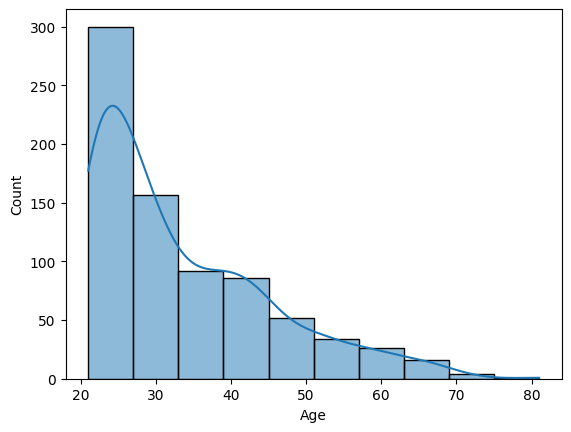

In [7]:
# step0: Plot histogram for 1 column: Age 

col = "Age"
sns.histplot(df[col], bins=10, kde=True) # kde--> Kernel Density Estimation 
plt.show()

# Now lets prettify above

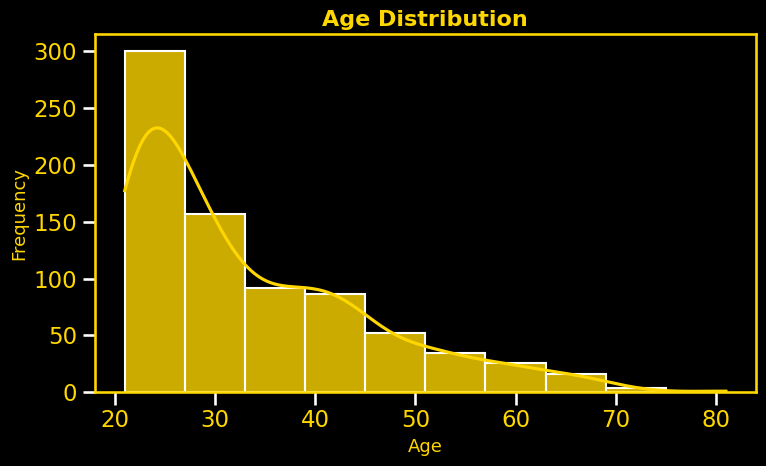

In [8]:
# step1: Prettify above. Plot histogram for 1 column: Age 

col = "Age"
plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

plt.figure(figsize=(8,5))

sns.histplot(df[col], bins=10, kde=True, color='gold', edgecolor='white', alpha=0.8, )

# Titles and labels
plt.title(f"{col} Distribution", fontsize=16, color='gold', fontweight='bold')
plt.xlabel(col, fontsize=13, color='gold')
plt.ylabel("Frequency", fontsize=13, color='gold')

# Customize ticks and spines
plt.xticks(color='gold')
plt.yticks(color='gold')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('gold')

# Show plot
plt.tight_layout()
plt.show()

# Obser: Most of employees are in age range of 26 to 40

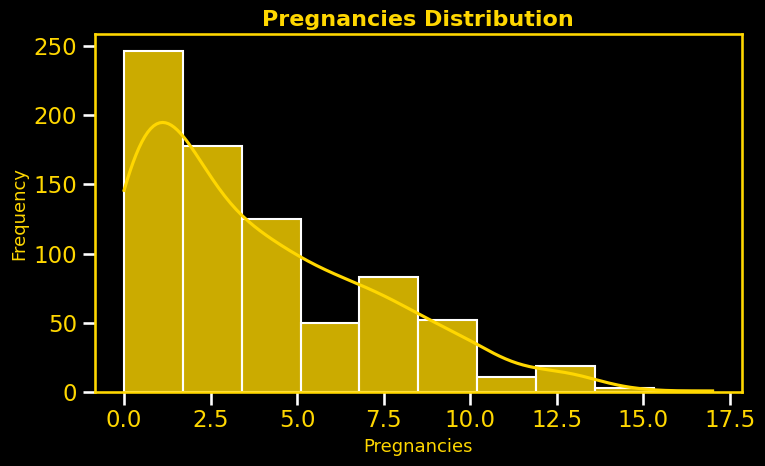

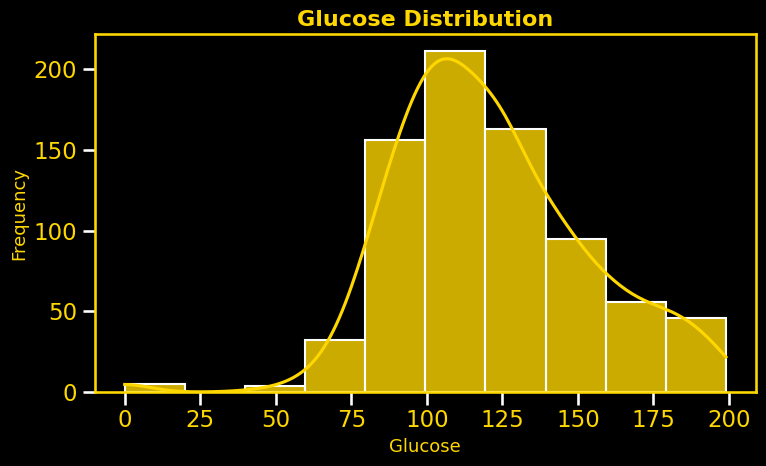

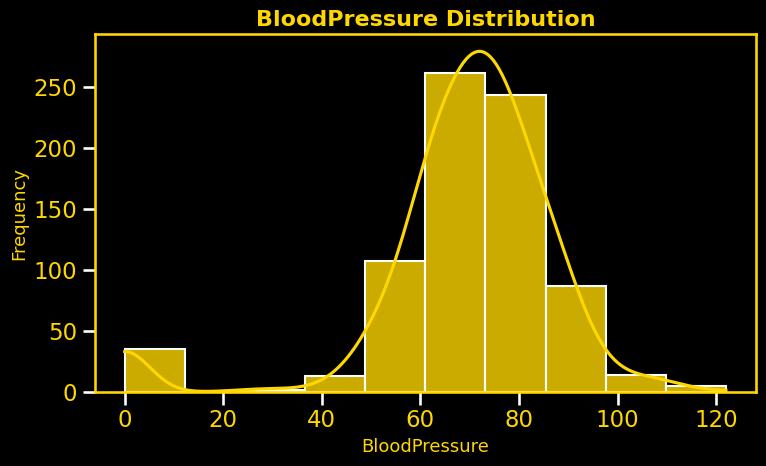

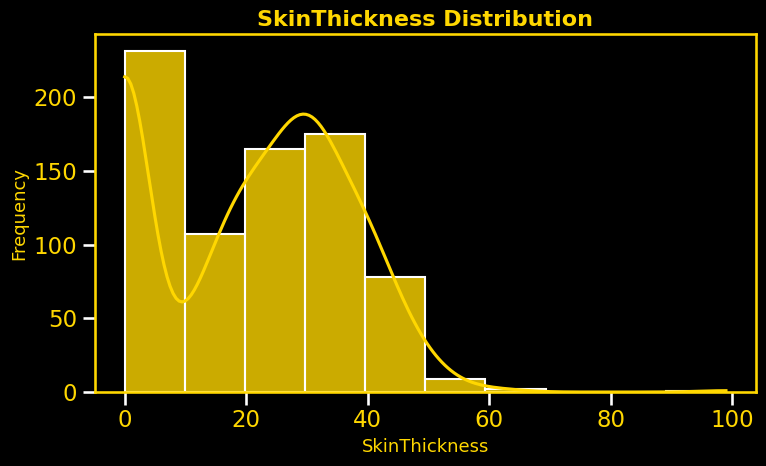

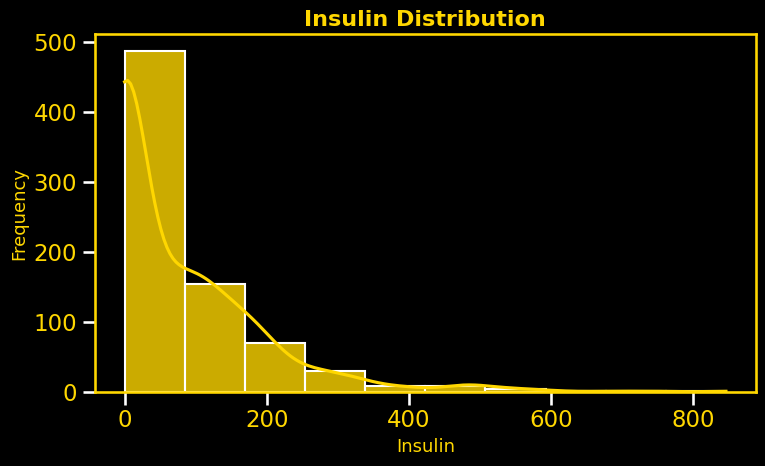

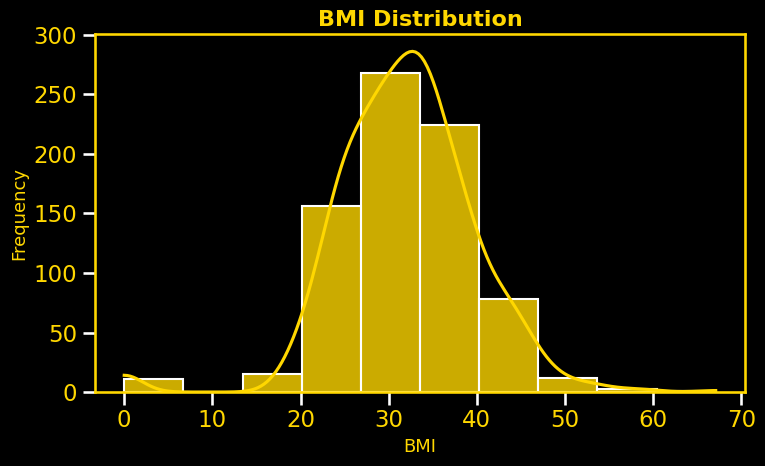

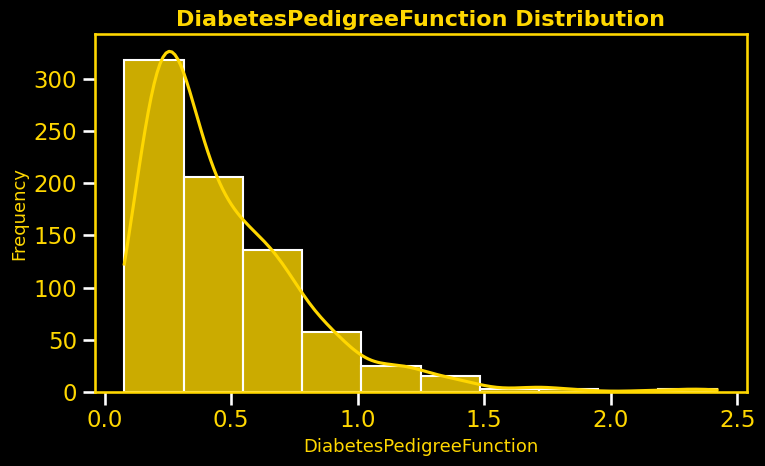

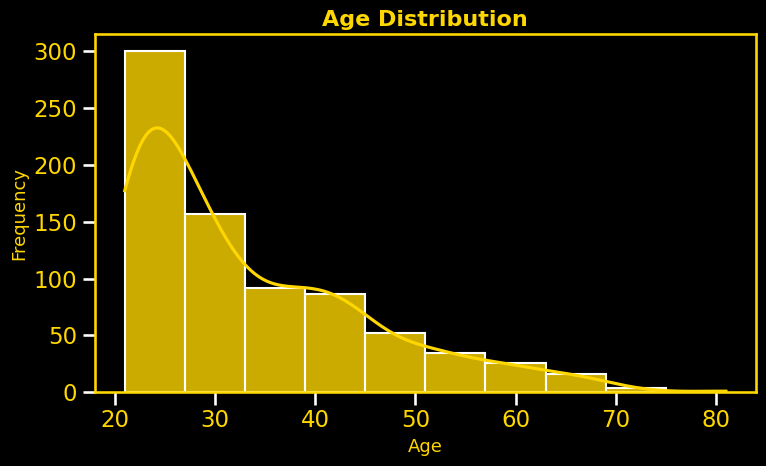

In [9]:
# step2: Now do this for few more columns: 

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', ]

for col in columns:
    
    plt.style.use("dark_background")  
    
    # Optional: control Seaborn palette and font scale
    sns.set_palette(["gold"])
    sns.set_context("talk")
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[col], bins=10, kde=True, color='gold', edgecolor='white', alpha=0.8)
    
    # Titles and labels
    plt.title(f"{col} Distribution", fontsize=16, color='gold', fontweight='bold')
    plt.xlabel(col, fontsize=13, color='gold')
    plt.ylabel("Frequency", fontsize=13, color='gold')
    
    # Customize ticks and spines
    plt.xticks(color='gold')
    plt.yticks(color='gold')
    for spine in plt.gca().spines.values():
        spine.set_edgecolor('gold')
    
    # Show plot
    plt.tight_layout()
    plt.show()

# observ: 


## Checking distribution of variables
- The histogram visually represents the distribution of the values in the specified feature. It shows how frequently different ranges of values appear in the data, which helps in understanding the feature's spread, central tendency, and any potential skewness or outliers.
  
- A Q-Q plot displays the quantiles of the feature's distribution against the quantiles of the normal distribution. **If the feature follows a normal distribution, the points should lie approximately on a straight line.**

In [10]:
import scipy.stats as stat
import pylab

def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist(color="MEDIUMVIOLETRED")
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show

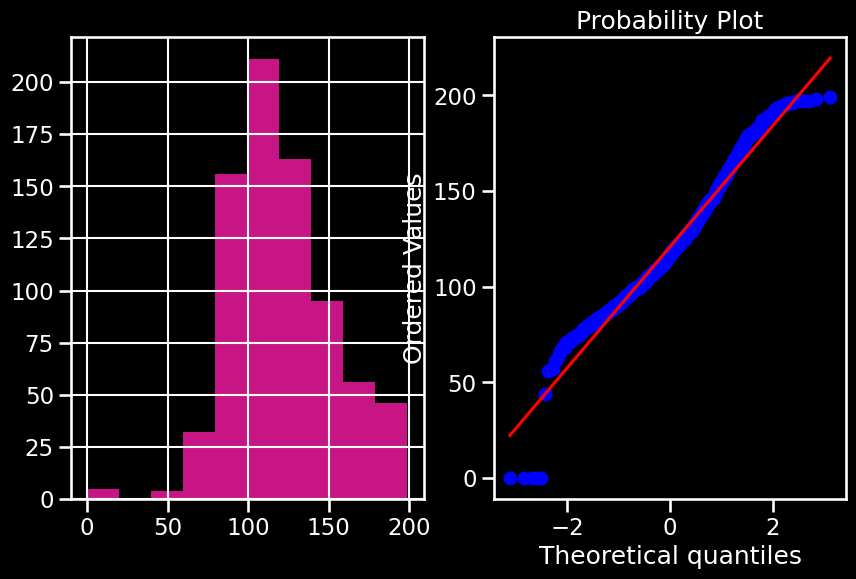

In [11]:
plot_data(df,'Glucose')

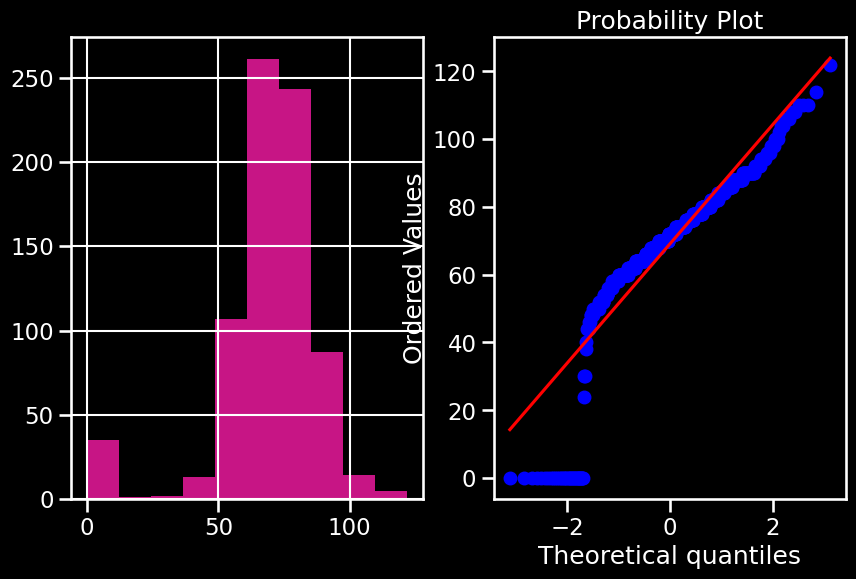

In [12]:
plot_data(df,'BloodPressure')

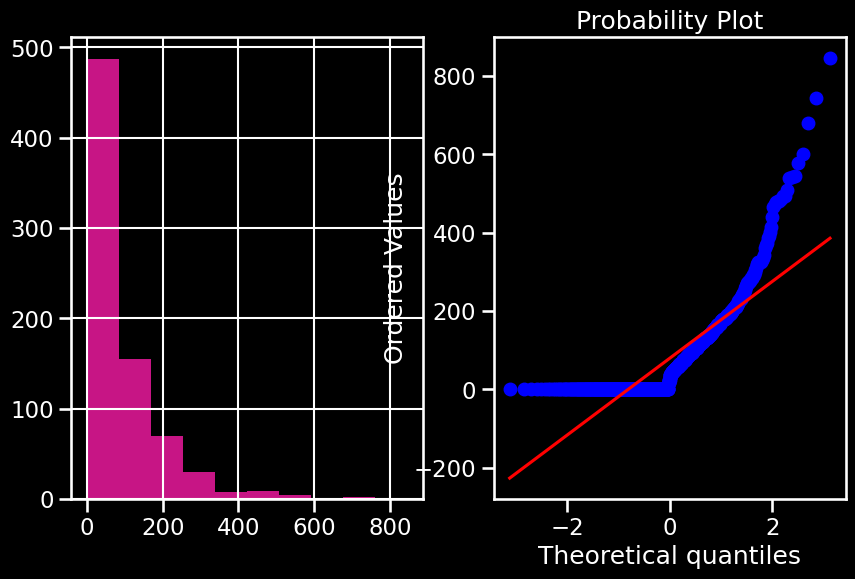

In [13]:
plot_data(df,'Insulin')

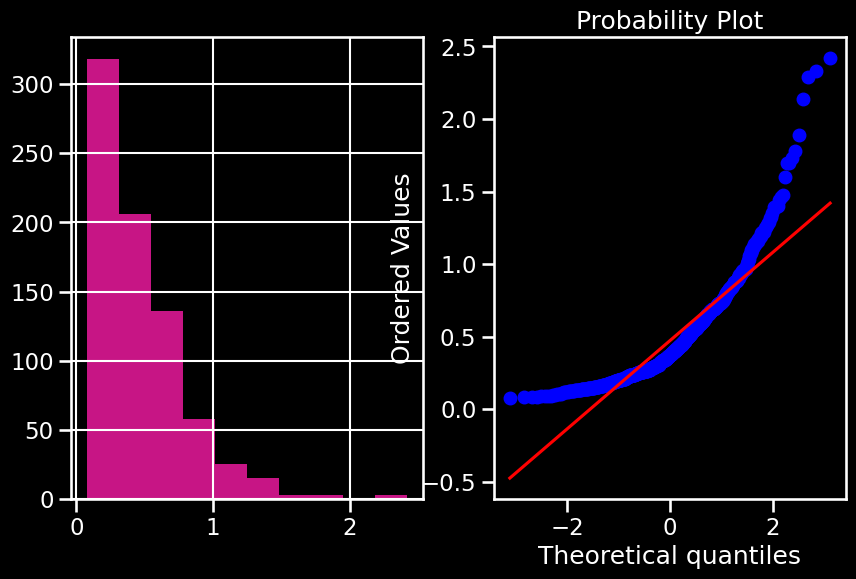

In [14]:
plot_data(df,'DiabetesPedigreeFunction')

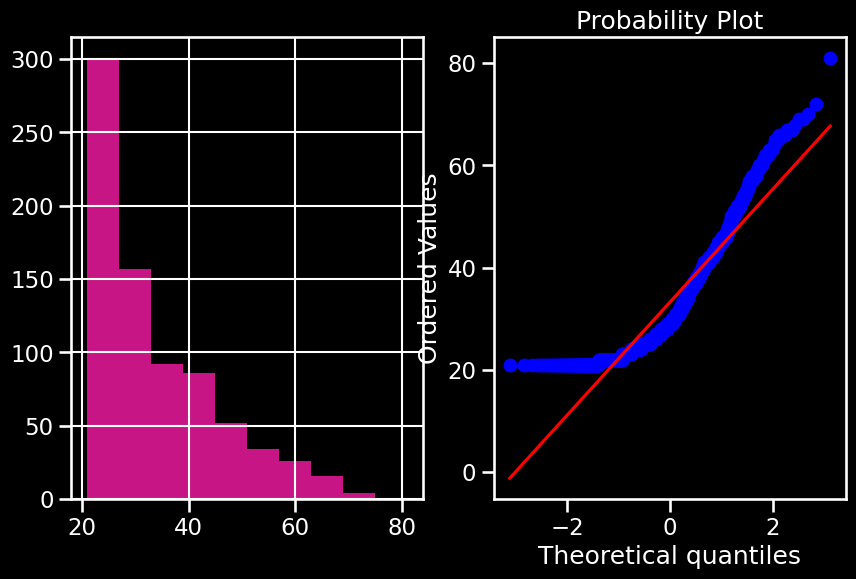

In [15]:
plot_data(df,'Age')

## Boxplot
Now I want to identify outliers and see the main  bulk of data lies

## Draw box plots
Compare data sets: Box plots are useful for comparing the distribution of data across multiple groups. 

Identify outliers: Box plots can show if there are any unusual values in the data set. 

Understand distribution: Box plots can show the shape of the distribution, including the center, spread, and skew. 

Answer questions: Box plots can help answer questions about the data, such as how it's distributed and if there are any outliers. 

### How do box plots work?
Box plots are based on a data set's quartiles, which divide the data into four equal parts.

The box represents the middle 50% of the data, with the top and bottom of the box representing the 75th and 25th percentiles. 

The distance between the 25th and 75th percentiles is called the interquartile range (IQR). 

The whiskers extend from the box to the furthest data point within 1.5 times the IQR. 

Data points that are further than that distance are considered outliers and are marked with a dot. 

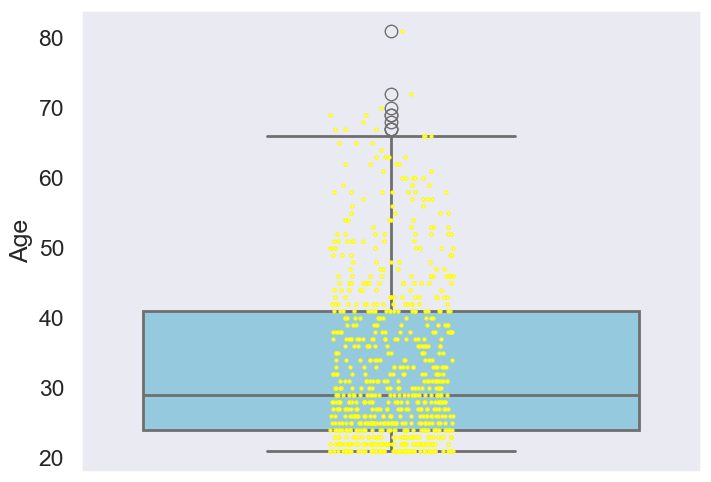

In [20]:
# step0: First do this for 1 columns

fig, ax = plt.subplots(figsize=(8, 6))
col = 'Age'

sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
# sns.stripplot(data=df, y=col, color='white', size=4, ax=ax, alpha=0.8)
sns.stripplot(  data=df, y=col,
    color='white',          # point fill color
    edgecolor='yellow',     # bright border
    linewidth=1.2,          # make outline visible
    size=2,                 # slightly bigger for emphasis
    ax=ax, alpha=0.9
)

plt.show()

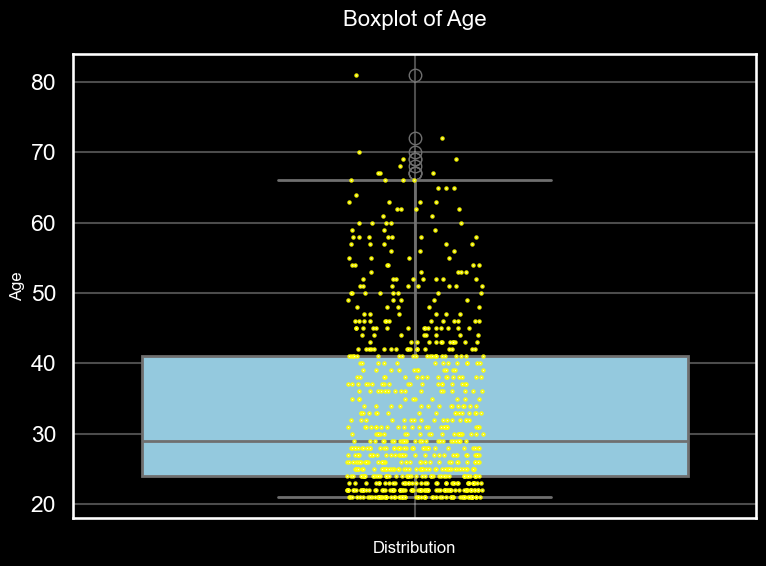

Q1 (25th percentile): 24.0
Q2 (Median, 50th percentile): 29.0
Q3 (75th percentile): 41.0
IQR (Q3 - Q1): 17.0
Outliers:
123    69
363    67
453    72
459    81
489    67
537    67
666    70
674    68
684    69
Name: Age, dtype: int8


In [21]:
# step1: Prettify.First do this for 1 columns

sns.set_style("dark")

fig, ax = plt.subplots(figsize=(8, 6))
col = 'Age'

sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
# sns.stripplot(data=df, y=col, color='white', size=4, ax=ax, alpha=0.8)
sns.stripplot(  data=df, y=col,
    color='white',          # point fill color
    edgecolor='yellow',     # bright border
    linewidth=1.2,          # make outline visible
    size=2,                 # slightly bigger for emphasis
    ax=ax, alpha=0.9
)


fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax.set_title(f'Boxplot of {col}', fontsize=16, color='white', pad=20)
ax.set_ylabel(col, fontsize=12, color='white')
ax.set_xlabel('Distribution', fontsize=12, color='white')
ax.grid(True, alpha=0.3, color='white')

# Make tick labels visible
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='x', colors='white')

plt.tight_layout()
plt.show()

# Calculate Q1, Q2, Q3, IQR
Q1 = df[col].quantile(0.25)
Q2 = df[col].quantile(0.5)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median, 50th percentile): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Q3 - Q1): {IQR}")

# Identify Outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

print(f"Outliers:\n{outliers}")

# Observ: 

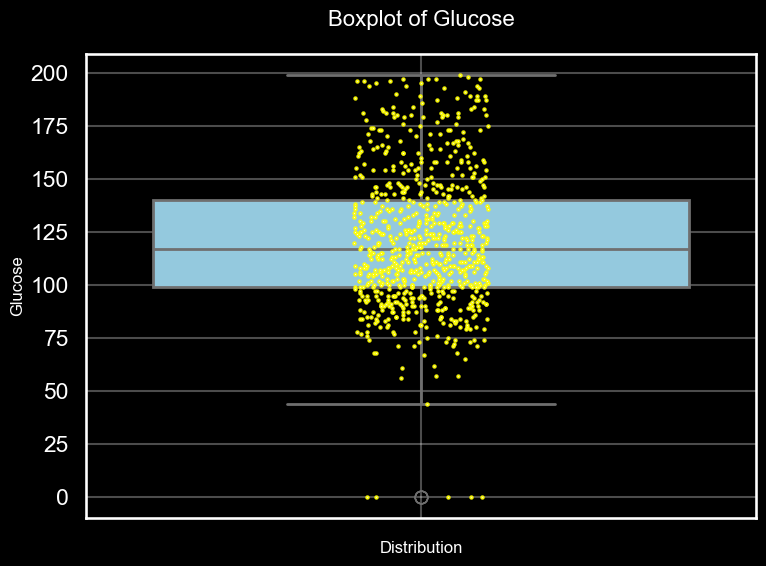

Q1 (25th percentile): 99.0
Q2 (Median, 50th percentile): 117.0
Q3 (75th percentile): 140.25
IQR (Q3 - Q1): 41.25
Outliers:
75     0
182    0
342    0
349    0
502    0
Name: Glucose, dtype: int16
+++++++++++++++++++++++++++++++




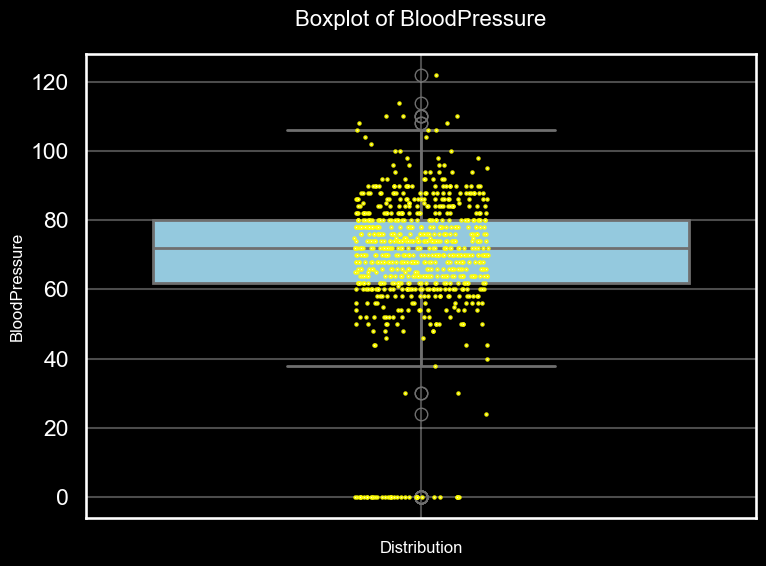

Q1 (25th percentile): 62.0
Q2 (Median, 50th percentile): 72.0
Q3 (75th percentile): 80.0
IQR (Q3 - Q1): 18.0
Outliers:
7        0
15       0
18      30
43     110
49       0
60       0
78       0
81       0
84     108
106    122
125     30
172      0
177    110
193      0
222      0
261      0
266      0
269      0
300      0
332      0
336      0
347      0
357      0
362    108
426      0
430      0
435      0
453      0
468      0
484      0
494      0
522      0
533      0
535      0
549    110
589      0
597     24
601      0
604      0
619      0
643      0
691    114
697      0
703      0
706      0
Name: BloodPressure, dtype: int8
+++++++++++++++++++++++++++++++




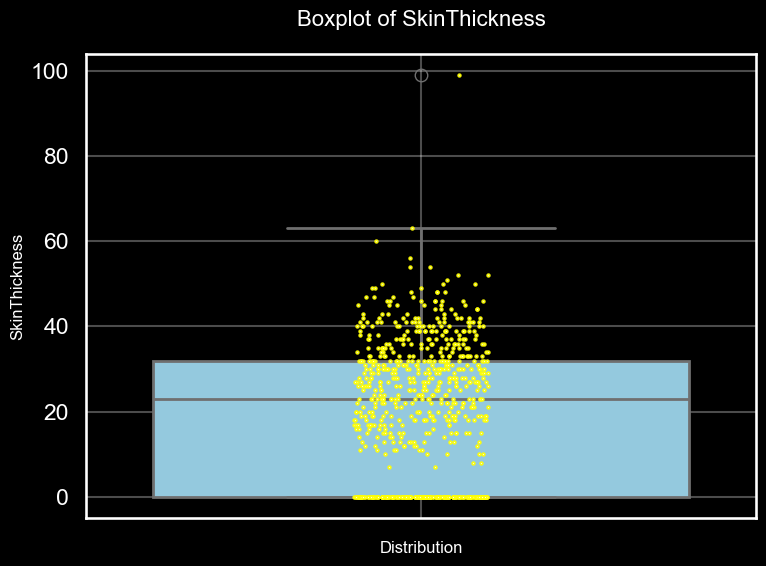

Q1 (25th percentile): 0.0
Q2 (Median, 50th percentile): 23.0
Q3 (75th percentile): 32.0
IQR (Q3 - Q1): 32.0
Outliers:
579    99
Name: SkinThickness, dtype: int8
+++++++++++++++++++++++++++++++




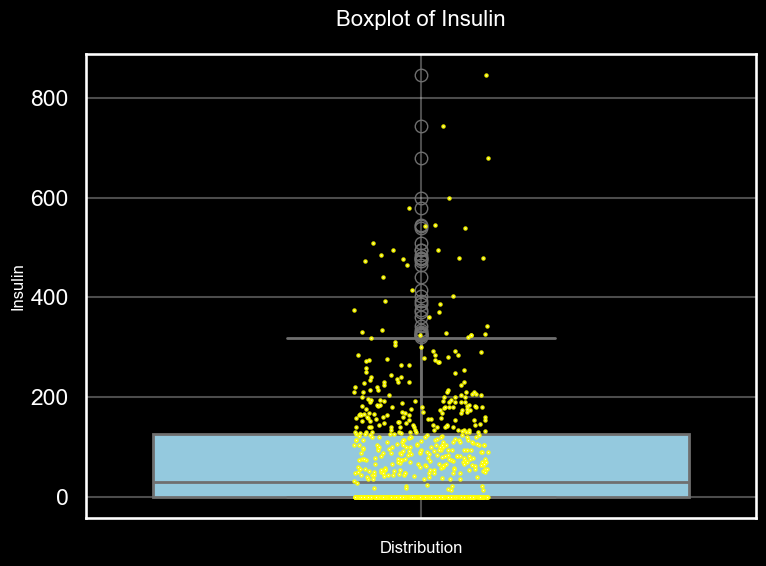

Q1 (25th percentile): 0.0
Q2 (Median, 50th percentile): 30.5
Q3 (75th percentile): 127.25
IQR (Q3 - Q1): 127.25
Outliers:
8      543
13     846
54     342
111    495
139    325
153    485
186    495
220    478
228    744
231    370
247    680
248    402
258    375
286    545
296    360
360    325
370    465
375    325
392    415
409    579
415    474
480    328
486    480
519    326
574    330
584    600
612    321
645    440
655    540
695    480
707    335
710    387
715    392
753    510
Name: Insulin, dtype: int16
+++++++++++++++++++++++++++++++




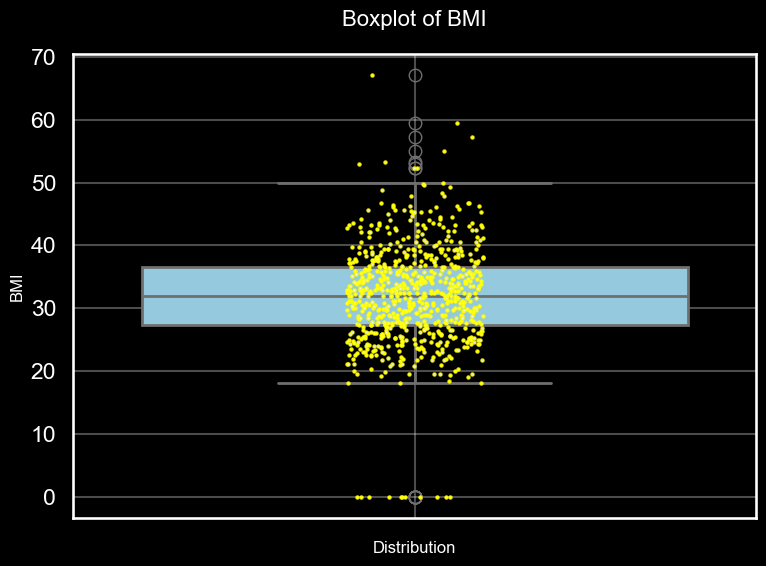

Q1 (25th percentile): 27.3
Q2 (Median, 50th percentile): 32.0
Q3 (75th percentile): 36.6
IQR (Q3 - Q1): 9.3
Outliers:
9       0.0
49      0.0
60      0.0
81      0.0
120    53.2
125    55.0
145     0.0
177    67.1
193    52.3
247    52.3
303    52.9
371     0.0
426     0.0
445    59.4
494     0.0
522     0.0
673    57.3
684     0.0
706     0.0
Name: BMI, dtype: float64
+++++++++++++++++++++++++++++++




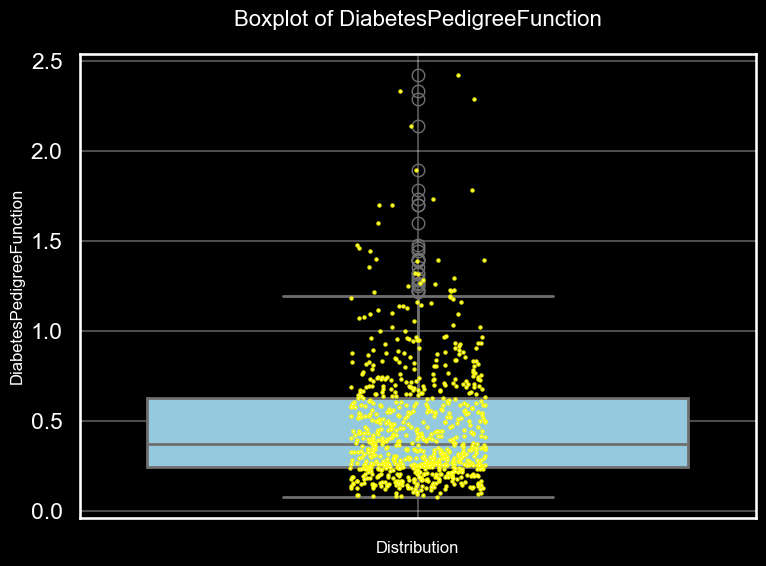

Q1 (25th percentile): 0.24375
Q2 (Median, 50th percentile): 0.3725
Q3 (75th percentile): 0.62625
IQR (Q3 - Q1): 0.38249999999999995
Outliers:
4      2.288
12     1.441
39     1.390
45     1.893
58     1.781
100    1.222
147    1.400
187    1.321
218    1.224
228    2.329
243    1.318
245    1.213
259    1.353
292    1.224
308    1.391
330    1.476
370    2.137
371    1.731
383    1.268
395    1.600
445    2.420
534    1.251
593    1.699
606    1.258
618    1.282
621    1.698
622    1.461
659    1.292
661    1.394
Name: DiabetesPedigreeFunction, dtype: float64
+++++++++++++++++++++++++++++++




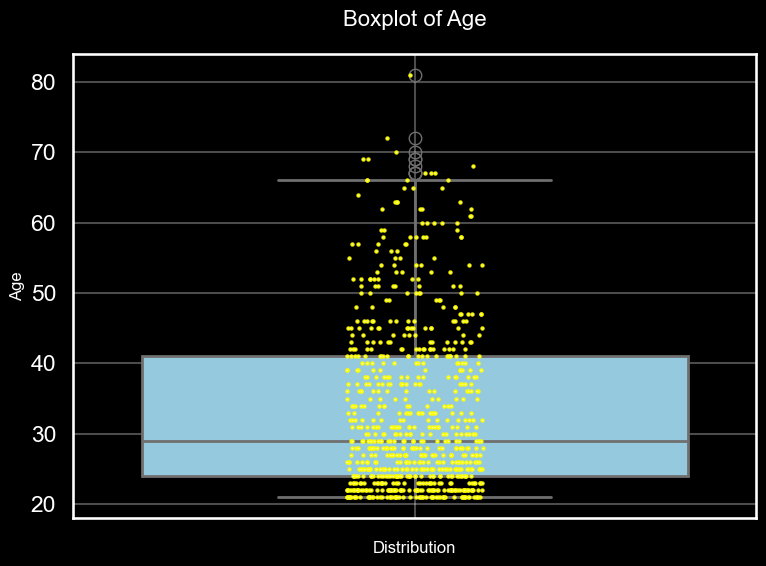

Q1 (25th percentile): 24.0
Q2 (Median, 50th percentile): 29.0
Q3 (75th percentile): 41.0
IQR (Q3 - Q1): 17.0
Outliers:
123    69
363    67
453    72
459    81
489    67
537    67
666    70
674    68
684    69
Name: Age, dtype: int8
+++++++++++++++++++++++++++++++




In [22]:
# step2: do this for all columns

columns = ['Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', ]


for col in columns:

    sns.set_style("dark")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
    # sns.stripplot(data=df, y=col, color='white', size=4, ax=ax, alpha=0.8)
    sns.stripplot(  data=df, y=col,
    color='white',          # point fill color
    edgecolor='yellow',     # bright border
    linewidth=1.2,          # make outline visible
    size=2,                 # slightly bigger for emphasis
    ax=ax, alpha=0.9
)

    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    
    ax.set_title(f'Boxplot of {col}', fontsize=16, color='white', pad=20)
    ax.set_ylabel(col, fontsize=12, color='white')
    ax.set_xlabel('Distribution', fontsize=12, color='white')
    ax.grid(True, alpha=0.3, color='white')
    
    # Make tick labels visible
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='x', colors='white')
    
    plt.tight_layout()
    plt.show()

    # Calculate Q1, Q2, Q3, IQR
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.5)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"Q1 (25th percentile): {Q1}")
    print(f"Q2 (Median, 50th percentile): {Q2}")
    print(f"Q3 (75th percentile): {Q3}")
    print(f"IQR (Q3 - Q1): {IQR}")
    
    # Identify Outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"Outliers:\n{outliers}")
    print("+++++++++++++++++++++++++++++++\n\n")


## Barplot for categorical columns

In [34]:
# Lets print categorical columns
cat_cols = ['Outcome']

print(cat_cols)

['Outcome']


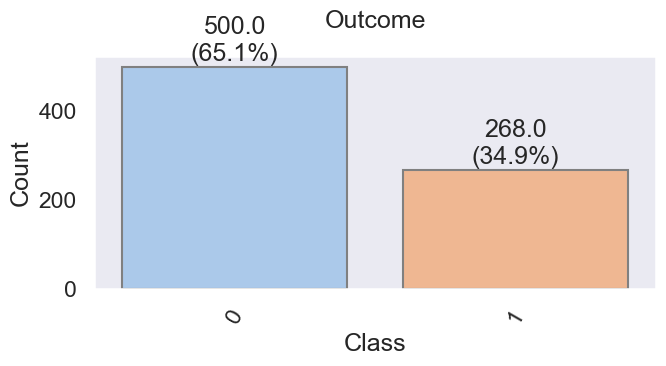

Category counts and percentages for 'Outcome':
   Outcome  Count  Percentage
0        0    500   65.104167
1        1    268   34.895833

---------------------------------------------



In [35]:
# step1: Do barplot for only one column
col = "Outcome"

plt.figure(figsize=(7, 4))
ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.title(f'{col}', pad=20)  # add padding between title and plot
plt.xlabel('Class')
plt.ylabel('Count')

plt.xticks(rotation=60)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
    ax.annotate(f'{height}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2, height + 3),
                ha='center', va='bottom')

plt.tight_layout()  # adjust subplots to give some padding
plt.show()

# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


## Bivariate Analysis
- Analysis of two variables to determine relationships between them.
- A positive correlation means that when one variable goes up, so does the other. A negative correlation shows that when one variable goes up, the other one goes down.

In [36]:
print(df.corr())

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

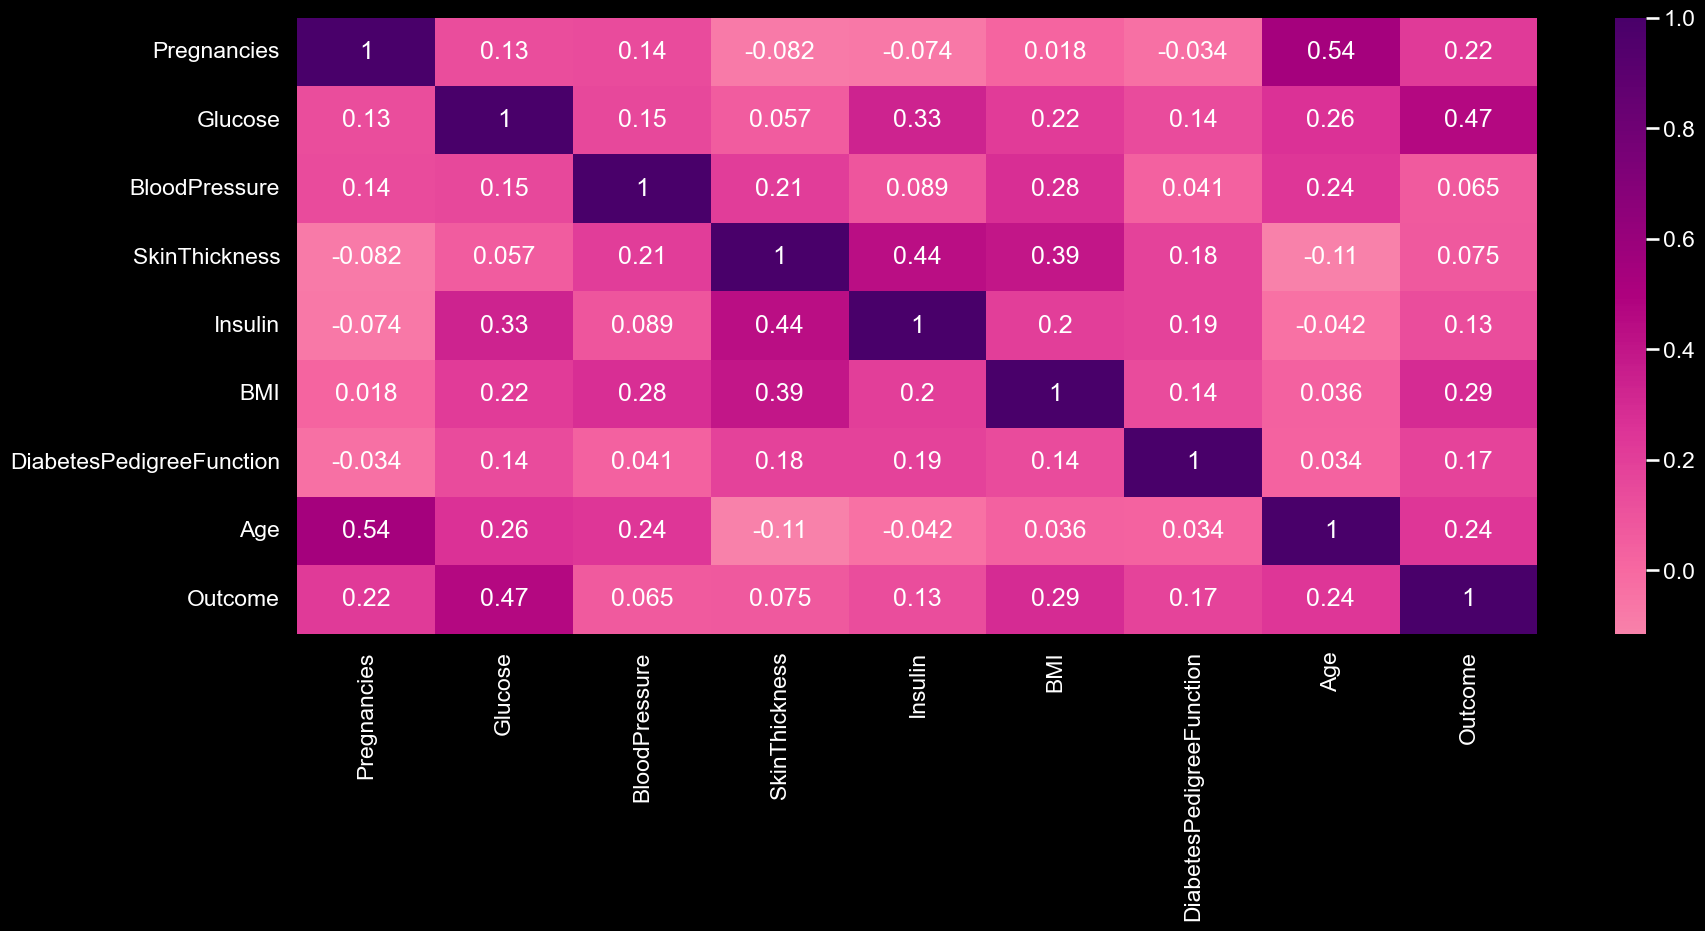

In [37]:
# The colors from below code helps identifying the strength of correlation. Darker color means high correlations
plt.style.use("dark_background")  
dataplot = sns.heatmap(df.corr(), cmap='RdPu', annot=True, center=0)
plt.show()

### If 2 variables are highly correlated, then we drop the one of them.

In [38]:
# In case if you are not able to see all the variables in heatmap, then 
# we can alternatively print all the pairs that have correlation coeff > 0.5.

columns = df.columns

for i in range(len(columns)-1):
    for j in range(i+1,len(columns)):
        if 0.5 <= df[columns[i]].corr(df[columns[j]]):
            print("We can drop either "+str(columns[i])+" or "+str(columns[j]))

We can drop either Pregnancies or Age


In [39]:
columns = columns[1:]
df.drop(['Pregnancies'], axis=1, inplace=True)
print(df.sample(10))

     Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
34       122             78             31        0  27.6   
375      140             82             43      325  39.2   
744      153             88             37      140  40.6   
216      109             62             41      129  35.8   
450       82             64             13       95  21.2   
729       92             52              0        0  30.1   
385      119             54             13       50  22.3   
438       97             70             15        0  18.2   
710      158             64             13      387  31.2   
119       99             76             15       51  23.2   

     DiabetesPedigreeFunction  Age  Outcome  
34                      0.512   45        0  
375                     0.528   58        1  
744                     1.174   39        0  
216                     0.514   25        1  
450                     0.415   23        0  
729                     0.141   22        0  
385   

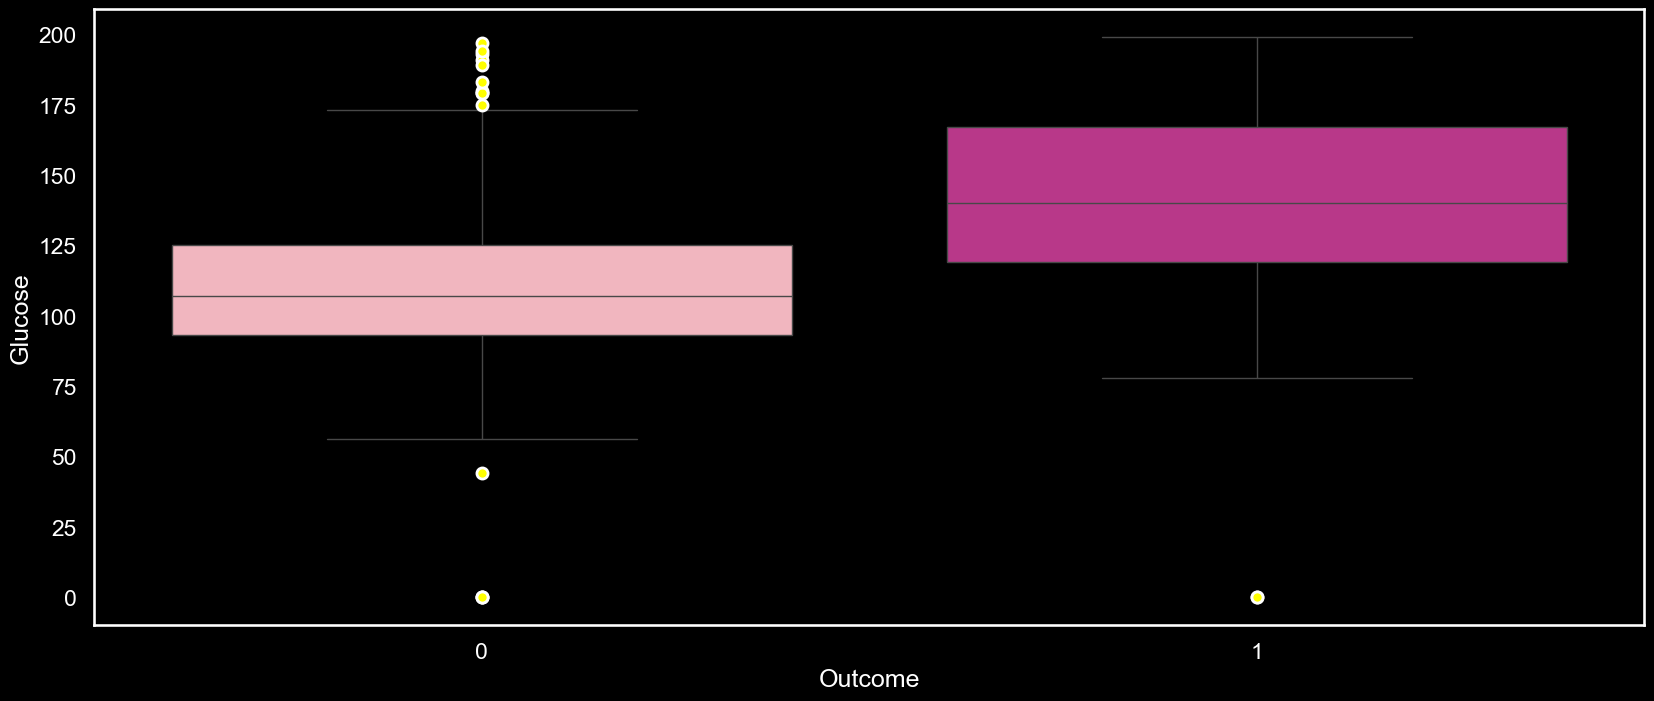

In [40]:
# Customize outlier appearance
flier_props = dict(marker='o',           # Marker shape
                   markerfacecolor='yellow',  # Bright fill color
                   markersize=8,         # Larger size
                   markeredgecolor='white',   # Bright edge color
                   markeredgewidth=2,    # Thick edge
                   alpha=1.0)            # Fully opaque

sns.boxplot(x='Outcome', y='Glucose', data=df, 
            palette="RdPu", flierprops=flier_props)

plt.show()

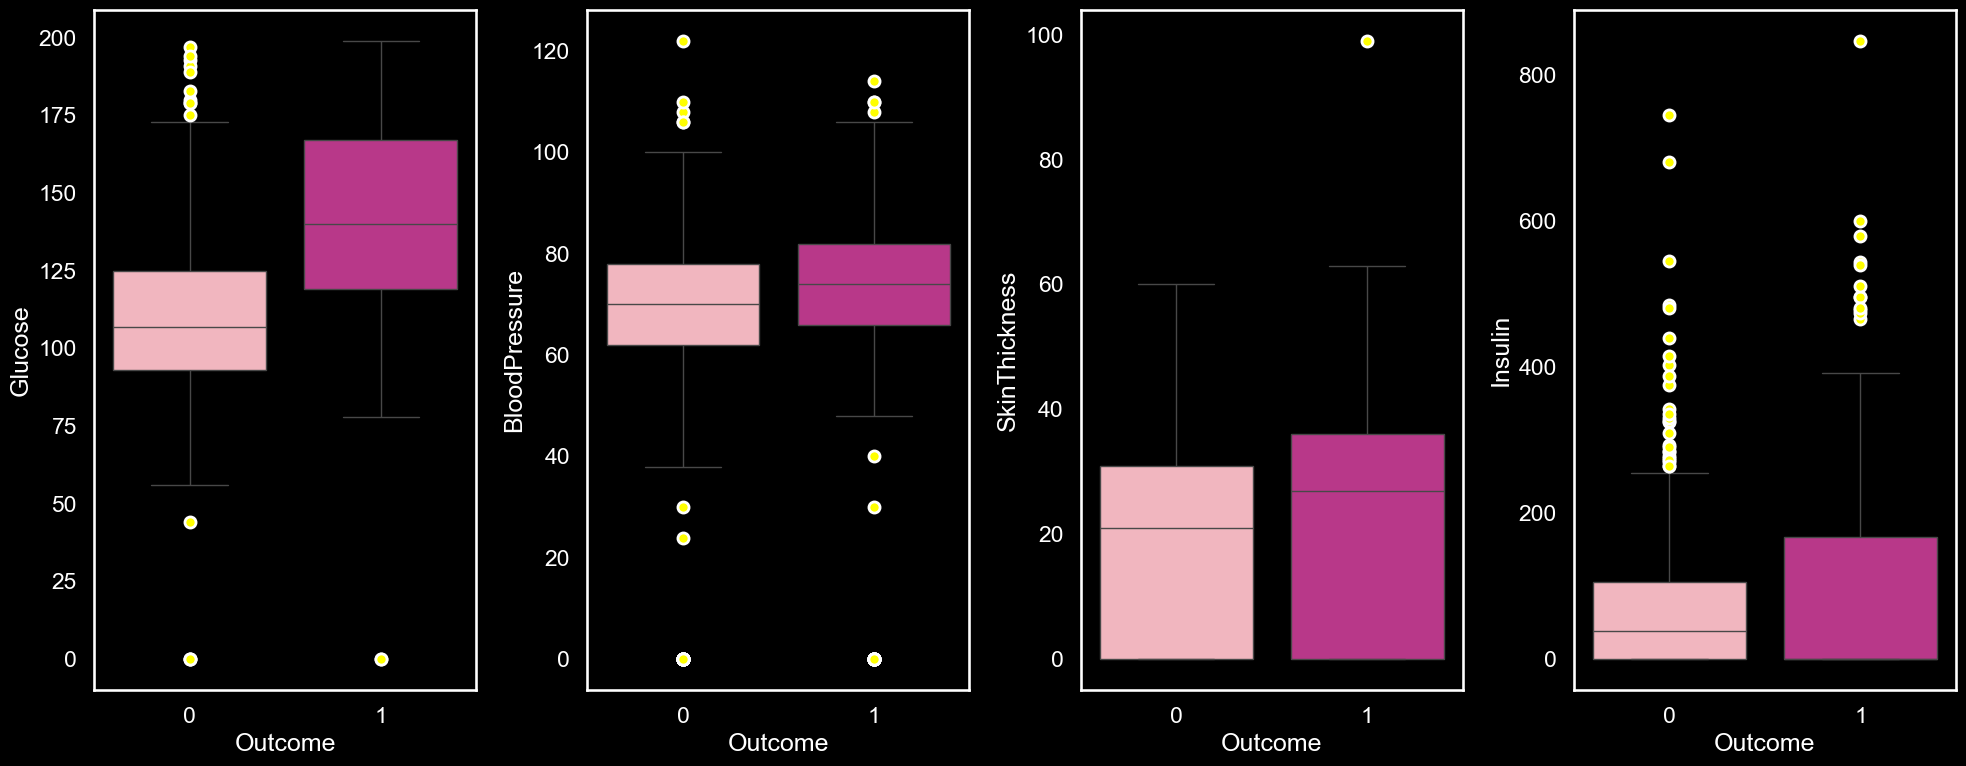

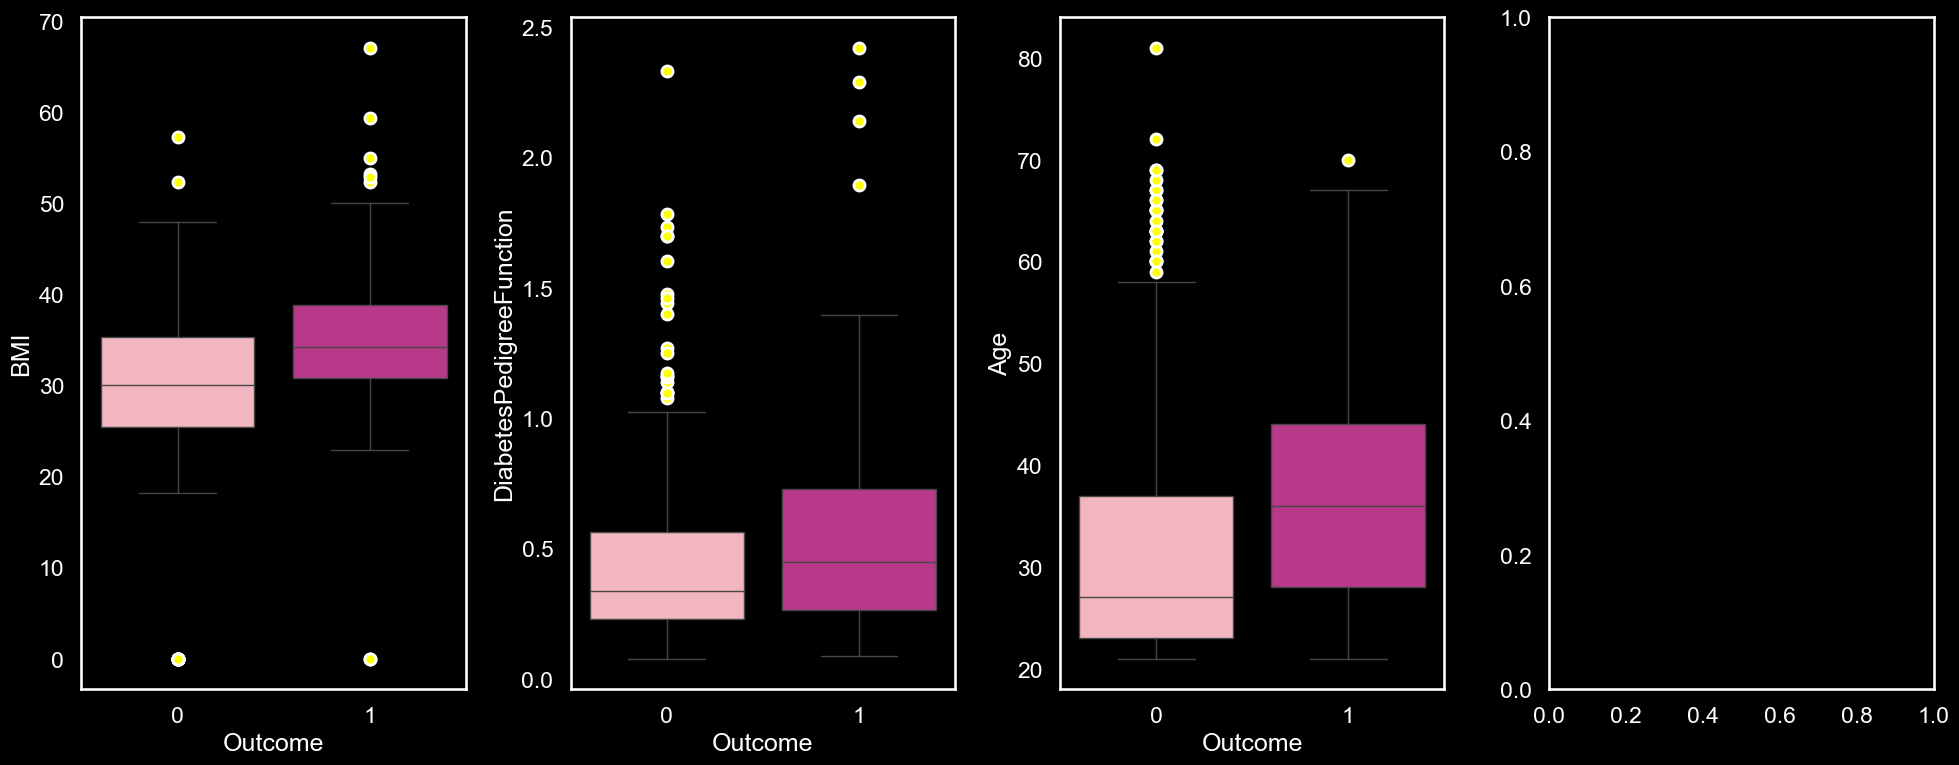

In [41]:
plt.rcParams['figure.figsize'] = (20, 8)
flier_props = dict(marker='o',           # Marker shape
                   markerfacecolor='yellow',  # Bright fill color
                   markersize=8,         # Larger size
                   markeredgecolor='white',   # Bright edge color
                   markeredgewidth=2,    # Thick edge
                   alpha=1.0)            # Fully opaque


# First row of boxplots
f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=ax1, palette="RdPu", flierprops=flier_props)
sns.boxplot(x='Outcome', y='BloodPressure', data=df, ax=ax2, palette="RdPu", flierprops=flier_props)
sns.boxplot(x='Outcome', y='SkinThickness', data=df, ax=ax3, palette="RdPu", flierprops=flier_props)
sns.boxplot(x='Outcome', y='Insulin', data=df, ax=ax4, palette="RdPu", flierprops=flier_props)

f.tight_layout()

# Second row of boxplots
f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)

sns.boxplot(x='Outcome', y='BMI', data=df, ax=ax1, palette="RdPu", flierprops=flier_props)
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, ax=ax2, palette="RdPu", flierprops=flier_props)
sns.boxplot(x='Outcome', y='Age', data=df, ax=ax3, palette="RdPu", flierprops=flier_props)

f.tight_layout()
plt.show()


In [42]:
df.to_pickle("data_Diabetes2.pkl")